# Airbnb Tokyo Price Prediction with E5 Embedding + Tabular LightGBM

`intfloat/multilingual-e5-small` で固定 embedding を作成し、その embedding に数値・カテゴリ変数を追加して LightGBM 回帰へ投入し $\log(\mathrm{price})$ を予測します。

## 基本情報

- 主題: Text embedding + LightGBM 回帰
- 作成者: 荒田禎之
- 位置づけ: fine-tuning を行わないテキスト回帰モデルの構築
- 使用データ: Inside Airbnb Tokyo listings
- 分析課題: listing の結合テキストから $\log(\mathrm{price})$ を予測
- 到達目標:
  - 固定 encoder で作った embedding と数値・カテゴリ変数を説明変数として LightGBM 回帰を学習する
  - mmBERT fine-tuning 版と比較しやすい軽量なテキストモデルを作る

This notebook includes code and explanations generated with OpenAI Codex.


In [1]:
# 必要なライブラリが未インストールの場合のみ、次の行のコメントを外してください。
# %pip install -q -U sentence-transformers lightgbm scikit-learn

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
SEED = 42


## 1. データの読み込み

`name`、`description`、`neighborhood_overview`、`host_about`、`amenities` を結合したテキストを使う。

Inside Airbnb Tokyo の listings URL から直接読み込む。


In [ ]:
DATA_URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2026-06-30/data/listings.csv.gz"
filename = "airbnb_tokyo_model_ready_eda.csv"
candidate_paths = [Path(filename), Path("data") / filename, Path("notebook") / filename]
csv_path = next((path for path in candidate_paths if path.exists()), None)

text_cols = [
    "name",
    "description",
    "neighborhood_overview",
    "host_about",
    "amenities",
]

numeric_features = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "availability_365",
    "latitude",
    "longitude",
    "host_listings_count",
]

categorical_features = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "host_is_superhost",
    "instant_bookable",
]

filter_cols = ["number_of_reviews"]
required_raw_cols = set(text_cols + numeric_features + categorical_features + ["price"])
min_text_cols_for_local = {"description", "name", "neighborhood_overview"}

if csv_path is not None:
    local_df = pd.read_csv(csv_path)
    local_text_cols = [col for col in text_cols if col in local_df.columns]
    local_numeric_cols = [col for col in numeric_features if col in local_df.columns]
    local_categorical_cols = [col for col in categorical_features if col in local_df.columns]
    has_price = "price_num" in local_df.columns or "price" in local_df.columns
    has_filter_cols = set(filter_cols).issubset(local_df.columns)
    if has_price and has_filter_cols and min_text_cols_for_local.issubset(local_df.columns):
        df = local_df
        print(f"Loaded local modeling data: {csv_path.resolve()}")
    else:
        print("Local file found, but it does not contain enough columns for this notebook.")
        print(f"Local text columns found: {local_text_cols}")
        print(f"Local numeric columns found: {local_numeric_cols}")
        print(f"Local categorical columns found: {local_categorical_cols}")
        df = pd.read_csv(
            DATA_URL,
            compression="gzip",
            low_memory=False,
            usecols=lambda col: col in required_raw_cols,
        )
        print(f"Loaded Inside Airbnb data from: {DATA_URL}")
else:
    df = pd.read_csv(
        DATA_URL,
        compression="gzip",
        low_memory=False,
        usecols=lambda col: col in required_raw_cols,
    )
    print(f"Loaded Inside Airbnb data from: {DATA_URL}")

rows_before = len(df)
available_text_cols = [col for col in text_cols if col in df.columns]
available_numeric_features = [col for col in numeric_features if col in df.columns]
available_categorical_features = [col for col in categorical_features if col in df.columns]
tabular_features = available_numeric_features + available_categorical_features
print(f"Original rows: {rows_before:,}")
print(f"Available text columns: {available_text_cols}")
print(f"Available numeric features: {available_numeric_features}")
print(f"Available categorical features: {available_categorical_features}")
display(df.head())


## 2. 結合テキストと目的変数

`number_of_reviews >= 5` の listing に絞り、そのサンプル内で `price_num` の下位0.1%と上位0.1%を除外する。複数のテキスト列は `Name: ...`、`Description: ...` のようにラベル付きで結合する。目的変数は $\log(\mathrm{price})$ とする。


In [ ]:
def clean_price(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    x = re.sub(r"[^0-9.]", "", str(x))
    return float(x) if x else np.nan


def clean_text_value(x):
    if pd.isna(x):
        return ""
    text = str(x)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def build_listing_text(row):
    labels = {
        "name": "Name",
        "description": "Description",
        "neighborhood_overview": "Neighborhood",
        "host_about": "Host",
        "amenities": "Amenities",
    }
    parts = []
    for col in available_text_cols:
        value = clean_text_value(row[col])
        if value:
            parts.append(f"{labels.get(col, col)}: {value}")
    return "\n".join(parts)


if "price_num" not in df.columns:
    if "price" not in df.columns:
        raise KeyError("`price_num` または `price` が必要です。")
    df["price_num"] = df["price"].apply(clean_price)

if not available_text_cols:
    raise KeyError("利用可能なテキスト列がありません。")
if "number_of_reviews" not in df.columns:
    raise KeyError("`number_of_reviews` が必要です。")
if not tabular_features:
    raise KeyError("利用可能な数値・カテゴリ特徴量がありません。")

df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")

base_mask = (
    df["price_num"].notna()
    & (df["price_num"] > 0)
    & df["number_of_reviews"].notna()
    & (df["number_of_reviews"] >= 5)
)
price_lower = df.loc[base_mask, "price_num"].quantile(0.001)
price_upper = df.loc[base_mask, "price_num"].quantile(0.999)
sample_mask = base_mask & df["price_num"].between(price_lower, price_upper)

print(f"Rows with positive price and number_of_reviews >= 5: {base_mask.sum():,}")
print(f"Price filter: {price_lower:,.0f} <= price_num <= {price_upper:,.0f}")
print(f"Rows after price 0.1% tail filtering: {sample_mask.sum():,}")

model_data = df.loc[
    sample_mask,
    available_text_cols + tabular_features + ["price_num"],
].copy()

for column in available_numeric_features:
    model_data[column] = pd.to_numeric(model_data[column], errors="coerce")

for column in available_categorical_features:
    model_data[column] = model_data[column].fillna("__MISSING__").astype("category")

model_data["text"] = model_data.apply(build_listing_text, axis=1)
model_data = (
    model_data.loc[model_data["text"].str.strip().ne("")]
    .drop_duplicates(subset=["text"])
    .reset_index(drop=True)
)
model_data["label"] = np.log(model_data["price_num"]).astype("float32")

print(f"Rows used after filtering and deduplication: {len(model_data):,}")
print(f"Numeric features: {available_numeric_features}")
print(f"Categorical features: {available_categorical_features}")
display(model_data[["text", "price_num", "number_of_reviews", "label"]].head())
display(model_data["label"].describe().rename("log_price").to_frame())


### 結合テキストの文字数

embedding model へ渡す前に、結合テキストの文字数分布を確認する。E5 encoder 側にも最大系列長があるため、極端に長いテキストは末尾が切り詰められる可能性がある。


,combined_text_length
count,22903.000000
mean,1417.837139
std,418.657633
min,169.000000
50%,1388.000000
75%,1654.000000
90%,1944.000000
95%,2130.000000
99%,2566.000000
max,5539.000000


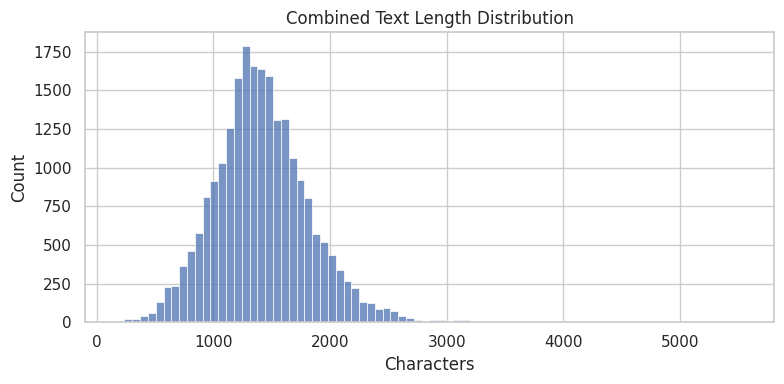

In [4]:
text_length = model_data["text"].str.len()
length_summary = text_length.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).rename("combined_text_length")
display(length_summary.to_frame())

plt.figure(figsize=(8, 4))
sns.histplot(text_length, bins=80)
plt.title("Combined Text Length Distribution")
plt.xlabel("Characters")
plt.tight_layout()
plt.show()


## 3. データ分割

80%を訓練、10%を検証、10%を最終テストに使う。LightGBM は検証データを early stopping に使い、最終性能はテストデータで評価する。


In [5]:
all_indices = np.arange(len(model_data))
train_indices, holdout_indices = train_test_split(
    all_indices, test_size=0.2, random_state=SEED
)
valid_indices, test_indices = train_test_split(
    holdout_indices, test_size=0.5, random_state=SEED
)

y = model_data["label"].to_numpy(dtype="float32")
y_train = y[train_indices]
y_valid = y[valid_indices]
y_test = y[test_indices]

print(f"Train: {len(train_indices):,}, validation: {len(valid_indices):,}, test: {len(test_indices):,}")


Train: 18,322, validation: 2,290, test: 2,291


## 4. `intfloat/multilingual-e5-small` による embedding

`intfloat/multilingual-e5-small` を固定 encoder として使い、fine-tuning は行わない。E5 系モデルでは通常、文書側テキストに `passage: ` prefix を付けるため、ここでも結合テキストの先頭に `passage: ` を付けて embedding を作る。

`normalize_embeddings=True` により L2 正規化済み embedding を作る。LightGBM 回帰はこの embedding に数値・カテゴリ変数を結合した特徴量を説明変数として学習する。


In [6]:
ENCODER_NAME = "intfloat/multilingual-e5-small"
BATCH_SIZE = 64
MAX_ROWS = None  # 動作確認だけ短時間で行う場合は 10_000 などを指定

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

if MAX_ROWS is not None and len(model_data) > MAX_ROWS:
    sampled_positions = np.sort(
        np.random.default_rng(SEED).choice(len(model_data), size=MAX_ROWS, replace=False)
    )
    model_data = model_data.iloc[sampled_positions].reset_index(drop=True)
    all_indices = np.arange(len(model_data))
    train_indices, holdout_indices = train_test_split(
        all_indices, test_size=0.2, random_state=SEED
    )
    valid_indices, test_indices = train_test_split(
        holdout_indices, test_size=0.5, random_state=SEED
    )
    y = model_data["label"].to_numpy(dtype="float32")
    y_train = y[train_indices]
    y_valid = y[valid_indices]
    y_test = y[test_indices]
    print(f"Rows after MAX_ROWS sampling: {len(model_data):,}")

encoder = SentenceTransformer(ENCODER_NAME, device=device)
encoder.eval()
for parameter in encoder.parameters():
    parameter.requires_grad = False

texts_for_embedding = [f"passage: {text}" for text in model_data["text"].tolist()]
embeddings = encoder.encode(
    texts_for_embedding,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

train_embeddings = embeddings[train_indices]
valid_embeddings = embeddings[valid_indices]
test_embeddings = embeddings[test_indices]
del embeddings

print(f"Train embedding shape: {train_embeddings.shape}")
print(f"Validation embedding shape: {valid_embeddings.shape}")
print(f"Test embedding shape: {test_embeddings.shape}")


Device: cuda


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/498k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/358 [00:00<?, ?it/s]

Train embedding shape: (18322, 384)
Validation embedding shape: (2290, 384)
Test embedding shape: (2291, 384)


## 5. embedding と表形式特徴量を結合した LightGBM 回帰

E5 embedding に、`airbnb_LightBGM.ipynb` と同じ数値・カテゴリ変数を追加して `LGBMRegressor` を学習する。カテゴリ列は pandas の `category` dtype のまま渡し、`categorical_feature` に列名を指定する。訓練データで学習し、検証データの RMSE を early stopping に使う。最終性能はテストデータで評価する。


In [ ]:
embedding_features = [f"embedding_{i:03d}" for i in range(train_embeddings.shape[1])]

def make_feature_frame(indices, embeddings_part):
    embedding_frame = pd.DataFrame(
        embeddings_part,
        columns=embedding_features,
        index=model_data.index[indices],
    )
    tabular_frame = model_data.iloc[indices][tabular_features].copy()
    feature_frame = pd.concat([embedding_frame, tabular_frame], axis=1)
    return feature_frame.reset_index(drop=True)


X_train = make_feature_frame(train_indices, train_embeddings)
X_valid = make_feature_frame(valid_indices, valid_embeddings)
X_test = make_feature_frame(test_indices, test_embeddings)

print(f"X_train shape: {X_train.shape}")
display(X_train.head())

model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    n_estimators=3_000,
    learning_rate=0.03,
    num_leaves=64,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    categorical_feature=available_categorical_features,
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=100)],
)

print(f"Best iteration: {model.best_iteration_:,}")
valid_pred = model.predict(X_valid)
validation_metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_valid, valid_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_valid, valid_pred),
    "R2 (log price)": r2_score(y_valid, valid_pred),
})
display(validation_metrics.to_frame("validation"))


## 6. テストデータでの評価

モデル選択に使っていないテストデータから log 価格を予測する。RMSE、MAE、$R^2$ は log 価格で計算し、参考として価格に戻した MAE も計算する。


In [8]:
y_pred = model.predict(X_test)

metrics = pd.Series({
    "RMSE (log price)": mean_squared_error(y_test, y_pred) ** 0.5,
    "MAE (log price)": mean_absolute_error(y_test, y_pred),
    "R2 (log price)": r2_score(y_test, y_pred),
    "MAE (price, JPY)": mean_absolute_error(np.exp(y_test), np.exp(y_pred)),
})
display(metrics.to_frame("value"))


,value
RMSE (log price),0.277929
MAE (log price),0.196052
R2 (log price),0.784102
"MAE (price, JPY)",5457.823196


### 予測値と残差の可視化

左図では実際の log 価格と予測 log 価格を散布図で比較し、右図では残差を「実際値 − 予測値」として表示する。


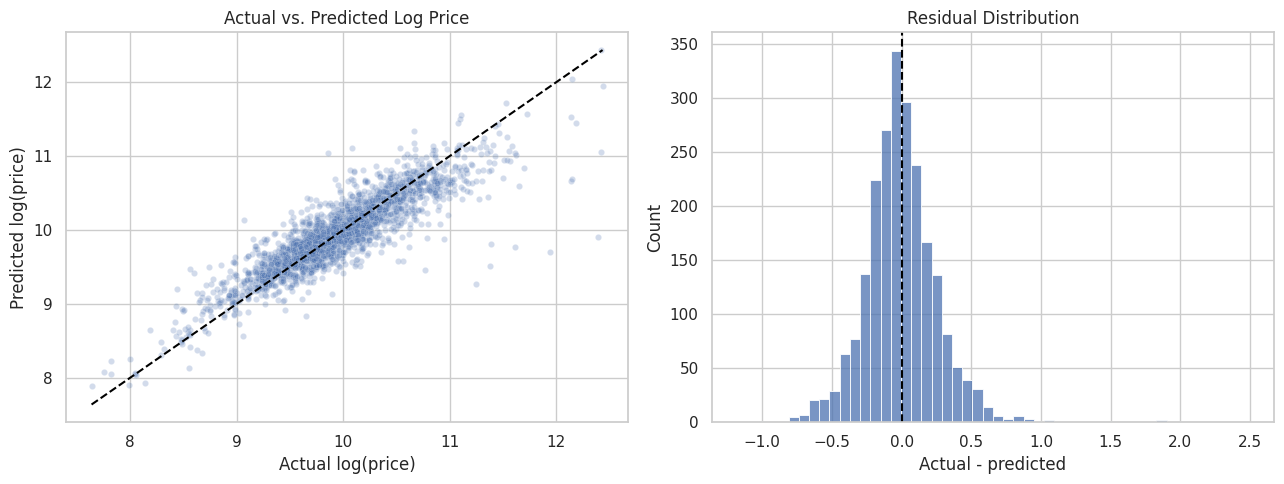

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.25, s=20, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black")
axes[0].set(
    title="Actual vs. Predicted Log Price",
    xlabel="Actual log(price)",
    ylabel="Predicted log(price)",
)

residuals = y_test - y_pred
sns.histplot(residuals, bins=50, ax=axes[1])
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set(title="Residual Distribution", xlabel="Actual - predicted")

plt.tight_layout()
plt.show()


## 7. 特徴量重要度

個々のembedding次元には直接的な意味を付けにくいため、全embedding次元の gain importance を合計し、`listing_text_embedding` として表示する。数値・カテゴリ特徴量と並べて、結合テキスト全体が予測にどの程度寄与したかを確認する。


,gain_importance_pct
listing_text_embedding,32.799564
accommodates,27.246488
bedrooms,9.725938
neighbourhood_cleansed,7.034892
property_type,5.392148
host_listings_count,3.476283
latitude,2.442756
review_scores_rating,2.003903
minimum_nights,1.654431
room_type,1.638276


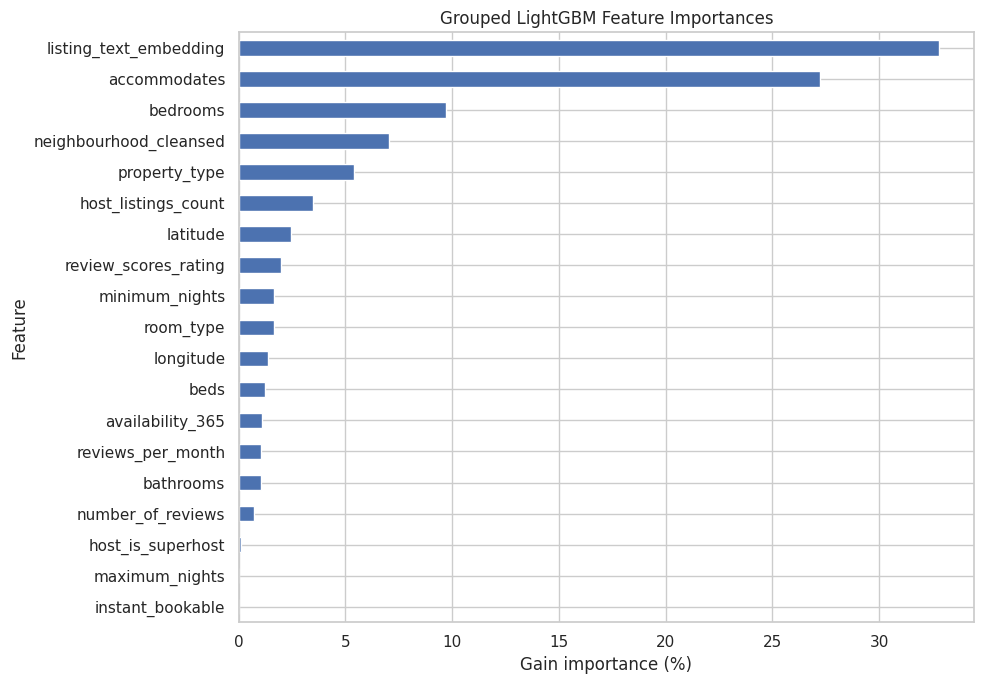

In [10]:
raw_importance = pd.Series(
    model.booster_.feature_importance(importance_type="gain"),
    index=model.booster_.feature_name(),
    name="gain_importance",
)

grouped_importance = pd.concat([
    raw_importance.reindex(tabular_features).fillna(0),
    pd.Series({
        "listing_text_embedding": raw_importance.reindex(embedding_features).fillna(0).sum(),
    }),
]).sort_values(ascending=False)

grouped_importance_pct = 100 * grouped_importance / grouped_importance.sum()
display(grouped_importance_pct.rename("gain_importance_pct").to_frame())

plt.figure(figsize=(10, 7))
grouped_importance_pct.sort_values().plot.barh()
plt.title("Grouped LightGBM Feature Importances")
plt.xlabel("Gain importance (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8. 予測結果の例

テストデータの先頭10件について、主な表形式特徴量、実際の価格、予測価格、入力テキストの冒頭を表示する。

In [ ]:
example_cols = [col for col in [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "number_of_reviews",
    "review_scores_rating",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
] if col in model_data.columns]

prediction_examples = model_data.iloc[test_indices].head(10)[
    example_cols + ["price_num", "text"]
].copy()
prediction_examples["text_preview"] = prediction_examples["text"].str.slice(0, 300)
prediction_examples = prediction_examples.drop(columns=["text"])
prediction_examples["actual_price"] = np.exp(y_test[:10])
prediction_examples["predicted_price"] = np.exp(model.predict(X_test.head(10)))
display(prediction_examples)


## 9. 新しい listing 情報から価格を予測

任意の listing 情報を辞書で渡し、学習時と同じ形式の結合テキストから embedding を作る。さらに数値・カテゴリ変数を同じ列構成で結合し、LightGBM で価格を予測する。


In [12]:
def make_text_from_listing(listing):
    labels = {
        "name": "Name",
        "description": "Description",
        "neighborhood_overview": "Neighborhood",
        "host_about": "Host",
        "amenities": "Amenities",
    }
    parts = []
    for col in text_cols:
        value = clean_text_value(listing.get(col, ""))
        if value:
            parts.append(f"{labels.get(col, col)}: {value}")
    return "\n".join(parts)


def make_single_feature_frame(listing, embedding):
    embedding_frame = pd.DataFrame(embedding, columns=embedding_features)
    tabular_values = {}
    for col in available_numeric_features:
        tabular_values[col] = pd.to_numeric(pd.Series([listing.get(col, np.nan)]), errors="coerce").iloc[0]
    for col in available_categorical_features:
        tabular_values[col] = listing.get(col, "__MISSING__")
    tabular_frame = pd.DataFrame([tabular_values])
    for col in available_categorical_features:
        tabular_frame[col] = tabular_frame[col].fillna("__MISSING__").astype("category")
    return pd.concat([embedding_frame, tabular_frame], axis=1)[X_train.columns]


def predict_price_from_listing(listing):
    text = make_text_from_listing(listing)
    embedding = encoder.encode(
        [f"passage: {text}"],
        batch_size=1,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")
    feature_frame = make_single_feature_frame(listing, embedding)
    predicted_log_price = float(model.predict(feature_frame)[0])
    return {
        "text": text,
        "log_price": predicted_log_price,
        "price_jpy": float(np.exp(predicted_log_price)),
    }


example_listing = {
    "name": "Private apartment near Shinjuku Station",
    "description": "A bright private apartment with fast Wi-Fi, compact kitchen, and washing machine.",
    "neighborhood_overview": "Convenient area with restaurants, convenience stores, and easy train access.",
    "host_about": "Experienced local host who responds quickly to guest questions.",
    "amenities": "Wifi, Kitchen, Washer, Air conditioning, Elevator",
    "accommodates": 2,
    "bedrooms": 1,
    "beds": 1,
    "bathrooms": 1,
    "minimum_nights": 2,
    "maximum_nights": 365,
    "number_of_reviews": 20,
    "review_scores_rating": 4.8,
    "reviews_per_month": 1.2,
    "availability_365": 180,
    "latitude": 35.69,
    "longitude": 139.70,
    "host_listings_count": 3,
    "room_type": "Entire home/apt",
    "property_type": "Entire rental unit",
    "neighbourhood_cleansed": "Shinjuku Ku",
    "host_is_superhost": "t",
    "instant_bookable": "f",
}
print(predict_price_from_listing(example_listing))


{'text': 'Name: Private apartment near Shinjuku Station\nDescription: A bright private apartment with fast Wi-Fi, compact kitchen, and washing machine.\nNeighborhood: Convenient area with restaurants, convenience stores, and easy train access.\nHost: Experienced local host who responds quickly to guest questions.\nAmenities: Wifi, Kitchen, Washer, Air conditioning, Elevator', 'log_price': 9.949603573419072, 'price_jpy': 20943.918010042606}
